In [1]:
from qiskit import __version__
print(__version__)

2.1.1


In [11]:
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace, DensityMatrix, Pauli
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.controlflow import IfElseOp
from qiskit.circuit.library import XGate, ZGate
import matplotlib.pyplot as plt
from collections import defaultdict
from typing import List

In [3]:
theta = np.arctan(np.sqrt((np.sqrt(5) - 1) / 2))
amp_0 = np.cos(theta/2)
amp_1 = np.sin(theta/2)

In [4]:
# Custom Hadamard 
h_sub = QuantumCircuit(1, name='H_custom')
h_sub.h(0)
H_custom = h_sub.to_gate()

# Custom CY
cy_sub = QuantumCircuit(2, name='CY_custom')
cy_sub.cy(0, 1)
CY_custom = cy_sub.to_gate()

# Custom S Gate
s_sub = QuantumCircuit(1, name='S_custom')
s_sub.s(0)
S_custom = s_sub.to_gate()

# Custom Sdg Gate
sdg_sub = QuantumCircuit(1, name='Sdg_custom')
sdg_sub.sdg(0)
Sdg_custom = sdg_sub.to_gate()

# Custom CZ Gate
cz_sub = QuantumCircuit(2, name='CZ_custom')
cz_sub.cz(0, 1)
CZ_custom = cz_sub.to_gate()

# Custom X Gate
x_sub = QuantumCircuit(1, name='X_custom')
x_sub.x(0)
X_custom = x_sub.to_gate()

# Custom Z Gate
z_sub = QuantumCircuit(1, name='Z_custom')
z_sub.z(0)
Z_custom = z_sub.to_gate()

# Functions for Encoding

In [5]:
def encoding(qc: QuantumCircuit, first_qubit: int):
    qc.ry(theta, first_qubit+3)
    qc.sdg(first_qubit+3)
    qc.h(first_qubit+3)
    qc.s(first_qubit+3)
    qc.h(first_qubit+2)
    qc.cy(first_qubit+2, first_qubit+3)
    qc.cz(first_qubit, first_qubit+2)
    qc.h(first_qubit+1)
    qc.cz(first_qubit+1, first_qubit+3)
    qc.cy(first_qubit+1, first_qubit+2)
    qc.h(first_qubit)
    qc.cz(first_qubit, first_qubit+2)
    qc.cy(first_qubit, first_qubit+1)

def inverse_encoding(qc: QuantumCircuit, first_qubit: int):
    qc.cy(first_qubit, first_qubit+1)
    qc.cz(first_qubit, first_qubit+2)
    qc.h(first_qubit)
    qc.cy(first_qubit+1, first_qubit+2)
    qc.cz(first_qubit+1, first_qubit+3)
    qc.h(first_qubit+1)
    qc.cz(first_qubit, first_qubit+2)
    qc.cy(first_qubit+2, first_qubit+3)
    qc.h(first_qubit+2)
    qc.sdg(first_qubit+3)
    qc.h(first_qubit+3)
    qc.s(first_qubit+3)
    qc.ry(-theta, first_qubit+3)

In [6]:
def perfect_encoding(qc: QuantumCircuit, first_qubit: int):
    qc.initialize([amp_0, amp_1], first_qubit+3)
    
    qc.append(Sdg_custom, [first_qubit+3])
    qc.append(H_custom, [first_qubit+3])
    qc.append(S_custom, [first_qubit+3])
    qc.append(H_custom, [first_qubit+2])
    qc.append(CY_custom, [first_qubit+2, first_qubit+3])
    qc.append(CZ_custom, [first_qubit, first_qubit+2])
    qc.append(H_custom, [first_qubit+1])
    qc.append(CZ_custom, [first_qubit+1, first_qubit+3])
    qc.append(CY_custom, [first_qubit+1, first_qubit+2])
    qc.append(H_custom, [first_qubit])
    qc.append(CZ_custom, [first_qubit, first_qubit+2])
    qc.append(CY_custom , [first_qubit, first_qubit+1])

# Simulation 

In [17]:
def decoder(memory: List[str]):
    shots = len(memory)
    error = 0
    for i in range(shots):
        if (memory[i] != '0000'):
            error += 1
    err_rate = error / shots
    unc = 1.96 * np.sqrt( (err_rate * (1 - err_rate) / shots ))
    return err_rate, unc

In [10]:
one_qubit_noise = []
for i in range(1, 7):
    one_qubit_noise.append(np.round((0.00002*i), 5)) # Quantinuum 1Q Gate
    
meas_noise = []
for i in range(1, 7):
    meas_noise.append(np.round((0.0015*i), 4)) # Quantinuum SPAM 
    
two_qubit_noise = []
for i in range(1, 7):
    two_qubit_noise.append(np.round((0.0016*i), 4)) # Quantinuum 2Q Gate

Text(0, 0.5, 'logical error')

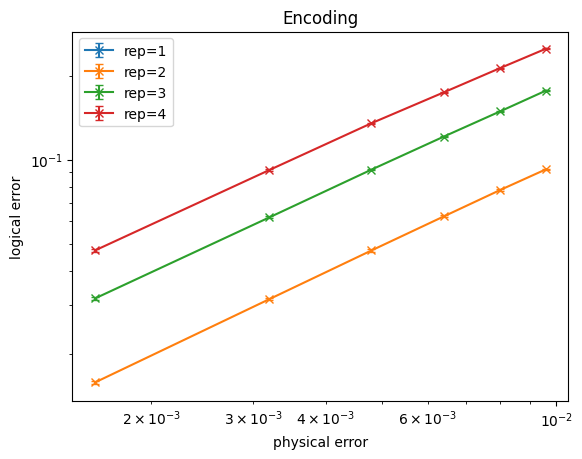

In [25]:
all_error = []
all_unc = []
for rep in range(1, 5):
    logical_error_rates = []
    unc = []
    for noise in range(len(one_qubit_noise)):
        #################################################################################
        # Error model
        noise_model = NoiseModel()
        
        #noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['id'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['h'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['ry'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['sdg'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(one_qubit_noise[noise],1), ['s'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_noise[noise],2), ['cz'])
        noise_model.add_all_qubit_quantum_error(depolarizing_error(two_qubit_noise[noise],2), ['cy'])

        # chance of flipping 0 <-> 1
        """
        readout_err = ReadoutError([[1-meas_noise[noise], meas_noise[noise]],  # P(measured 0 | actual 0), P(1 | 0)
                                    [meas_noise[noise], 1-meas_noise[noise]]]) # P(0 | 1), P(1 | 1)

        # Apply to all qubits being measured
        noise_model.add_readout_error(readout_err, [0]) 
        noise_model.add_readout_error(readout_err, [1])
        noise_model.add_readout_error(readout_err, [2])
        noise_model.add_readout_error(readout_err, [3])
        """
        #################################################################################
        qc = QuantumCircuit(4)
        c = ClassicalRegister(4, "c")
        qc.add_register(c)

        for i in range(1, rep):
            encoding(qc, 0)
            inverse_encoding(qc, 0)
        qc.measure([0, 1, 2, 3], c)
        #################################################################################
        backend = AerSimulator(noise_model=noise_model)
        transpiled = transpile(qc, backend, optimization_level=0)
        job = backend.run(transpiled, shots=1_000_000, memory=True)
        result = job.result()
        memory = result.get_memory()
        #################################################################################
        err_rate, u = decoder(memory)
        logical_error_rates.append(err_rate)
        unc.append(u)
    
    plt.errorbar(
        two_qubit_noise,
        logical_error_rates,
        yerr=unc,
        fmt='-x',
        label=f'rep={rep}',
        capsize=3  # little horizontal caps on the error bars
    )
    all_error.append(logical_error_rates)
    all_unc.append(unc)
    
plt.title('Encoding')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('physical error')
plt.ylabel('logical error')

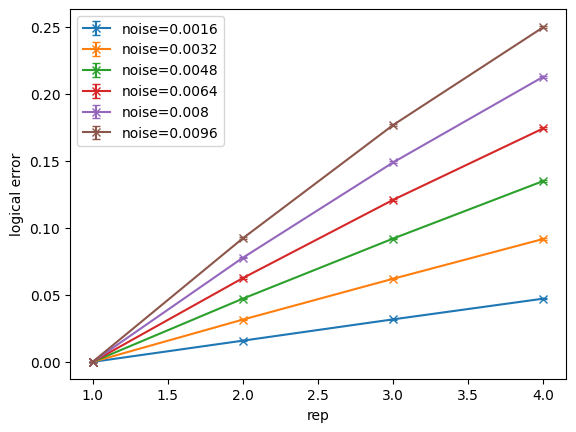

In [26]:
# all_error.shape == (num_reps, num_noises)
# uncertainties.shape == (num_reps, num_noises)
all_error = np.array(all_error)
all_unc = np.array(all_unc)
num_reps, num_noises = all_error.shape

x = range(1, 5)

for k in range(num_noises):
    plt.errorbar(
        x,
        all_error[:, k],
        yerr=all_unc[:, k],
        fmt='-x',
        capsize=3,
        label=f'noise={two_qubit_noise[k]}'
    )

plt.legend()
plt.xlabel('rep')
plt.ylabel('logical error')
plt.show()

In [28]:
x = np.array(list(range(1, 5)))   
slopes = []

for k, noise in enumerate(two_qubit_noise):
    y = all_error[:, k]               # error vs rep for this noise
    m, b = np.polyfit(x, y, 1)
    slopes.append(m)
    print(f"noise={noise:0.4f} → slope = {m:.4f} per rep")

noise=0.0016 → slope = 0.0158 per rep
noise=0.0032 → slope = 0.0306 per rep
noise=0.0048 → slope = 0.0450 per rep
noise=0.0064 → slope = 0.0581 per rep
noise=0.0080 → slope = 0.0710 per rep
noise=0.0096 → slope = 0.0834 per rep
